In [1]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

## Load and Display Chest X-ray Dataset

In [2]:
IMG_SIZE = 64  # resize all images to 64x64 pixels

def load_images_from_folder(folder, label, img_size=IMG_SIZE):
    images = []
    labels = []
    for filename in sorted(os.listdir(folder)):
        if not filename.lower().endswith(('.jpeg', '.jpg', '.png')):
            continue
        filepath = os.path.join(folder, filename)
        img = Image.open(filepath).convert('L')  # convert to grayscale
        img = img.resize((img_size, img_size))
        img_array = np.array(img).flatten() / 255.0  # flatten and normalize to [0,1]
        images.append(img_array)
        labels.append(label)
    return images, labels

data_dir = 'dataset/chest_xray'

# Load training data (NORMAL = 0, PNEUMONIA = 1)
train_normal_imgs, train_normal_labels = load_images_from_folder(
    os.path.join(data_dir, 'train', 'NORMAL'), label=0)
train_pneumonia_imgs, train_pneumonia_labels = load_images_from_folder(
    os.path.join(data_dir, 'train', 'PNEUMONIA'), label=1)

X_train = np.array(train_normal_imgs + train_pneumonia_imgs)
y_train = np.array(train_normal_labels + train_pneumonia_labels).reshape(-1, 1)

# Load test data
test_normal_imgs, test_normal_labels = load_images_from_folder(
    os.path.join(data_dir, 'test', 'NORMAL'), label=0)
test_pneumonia_imgs, test_pneumonia_labels = load_images_from_folder(
    os.path.join(data_dir, 'test', 'PNEUMONIA'), label=1)

X_test = np.array(test_normal_imgs + test_pneumonia_imgs)
y_test = np.array(test_normal_labels + test_pneumonia_labels).reshape(-1, 1)

print('X_train.shape', X_train.shape)
print('X_test.shape', X_test.shape)
print('y_train.shape', y_train.shape)
print('y_test.shape', y_test.shape)

X_train.shape (5232, 4096)
X_test.shape (624, 4096)
y_train.shape (5232, 1)
y_test.shape (624, 1)


In [3]:
# Check class distribution
print('Training set:')
print('  NORMAL:', np.sum(y_train == 0))
print('  PNEUMONIA:', np.sum(y_train == 1))
print('Test set:')
print('  NORMAL:', np.sum(y_test == 0))
print('  PNEUMONIA:', np.sum(y_test == 1))

Training set:
  NORMAL: 1349
  PNEUMONIA: 3883
Test set:
  NORMAL: 234
  PNEUMONIA: 390


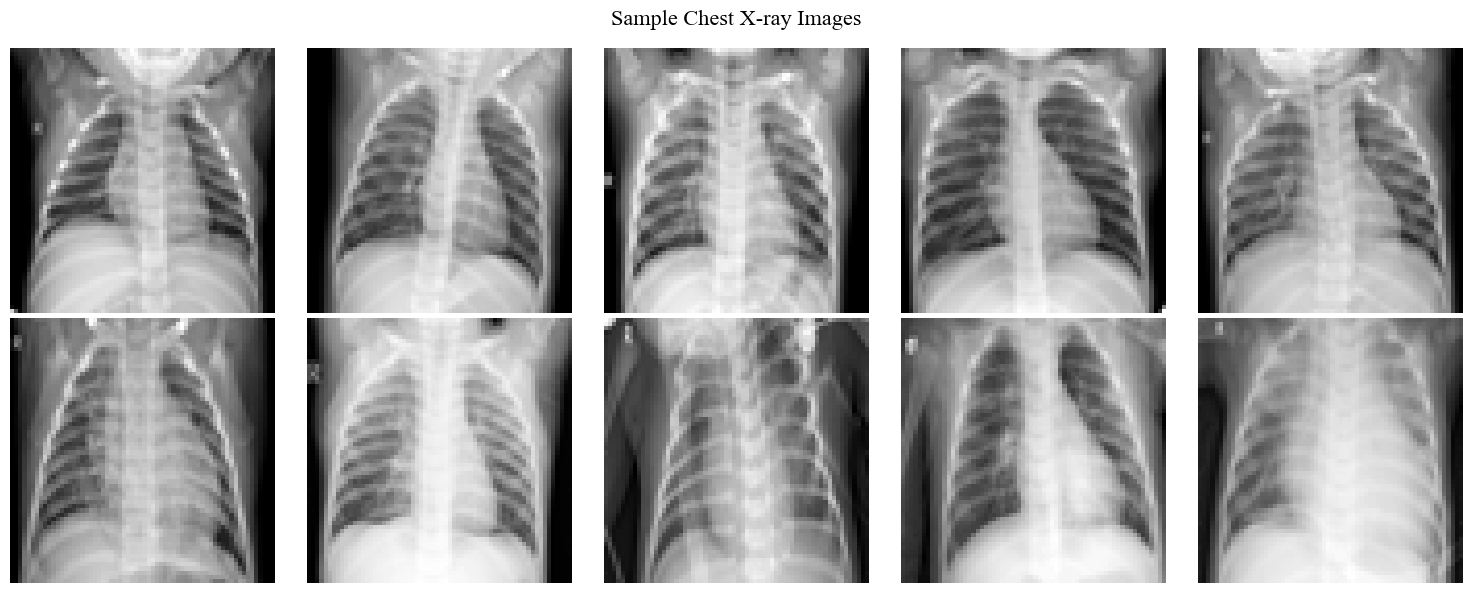

In [4]:
# Plot some sample images
ncols = 5
nrows = 2
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=[15, 6])
class_names = ['NORMAL', 'PNEUMONIA']
for i in range(nrows):
    idx = np.where(y_train.flatten() == i)[0]
    samples = np.random.choice(idx, ncols, replace=False)
    for j in range(ncols):
        ax[i, j].imshow(X_train[samples[j]].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        ax[i, j].axis('off')
        if j == 0:
            ax[i, j].set_ylabel(class_names[i], fontsize=14)
fig.suptitle('Sample Chest X-ray Images', fontsize=16)
plt.tight_layout()

## Dimensionality Reduction with PCA

Since the input dimensionality is high (64 x 64 = 4096 features per image), we use PCA to reduce the feature space before training.

X_train_pca.shape (5232, 50)
X_test_pca.shape (624, 50)
Cumulative explained variance: 0.8583


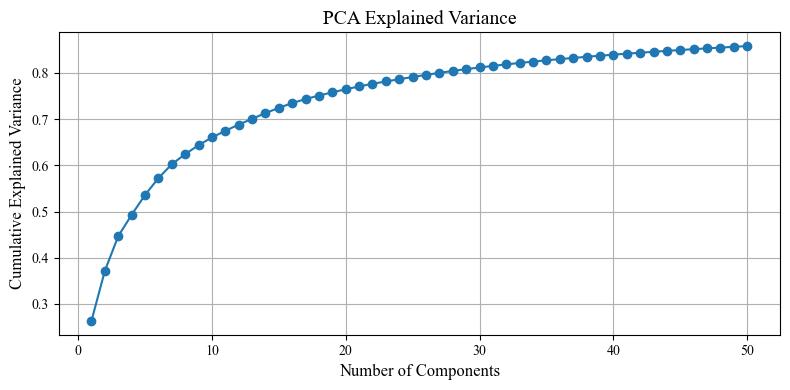

In [5]:
n_components = 50
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print('X_train_pca.shape', X_train_pca.shape)
print('X_test_pca.shape', X_test_pca.shape)
print('Cumulative explained variance:', np.round(np.sum(pca.explained_variance_ratio_), 4))

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=[8, 4])
ax.plot(np.arange(1, n_components + 1), np.cumsum(pca.explained_variance_ratio_), 'o-')
ax.set_xlabel('Number of Components', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('PCA Explained Variance', fontsize=14)
ax.grid(True)
plt.tight_layout()

## Logistic Regression

Binary Logistic Regression:  \sim \text{Bernoulli}(Q)$,  = \sigma(H^T W)$ where $\sigma(x) = e^x/(1+e^x)$.

MLE: Find $\hat{W} = \arg\min_W \sum_j \left( \log(1+e^{H_j^T W}) - Y^T H^T W \right)$

In [6]:
# sigmoid function
def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

In [7]:
def fit_LR_GD(Y, H, W0=None, sub_iter=100, stopping_diff=0.01):
    '''
    Convex optimization for Logistic Regression using Gradient Descent
    Y = (n x 1), H = (p x n) (Phi in lecture notes), W = (p x 1)
    Logistic Regression: Y ~ Bernoulli(Q), Q = sigmoid(H.T @ W)
    MLE -->
    Find W_hat = argmin_W ( sum_j ( log(1+exp(H_j.T @ W) ) - Y.T @ H.T @ W ) )
    '''
    if W0 is None:
        W0 = np.random.rand(H.shape[0], 1)

    W1 = W0.copy()
    i = 0
    grad = np.ones(W0.shape)
    while (i < sub_iter) and (np.linalg.norm(grad) > stopping_diff):
        Q = 1 / (1 + np.exp(-H.T @ W1))  # probability matrix, same shape as Y
        grad = H @ (Q - Y)
        W1 = W1 - (np.log(i + 1) / (((i + 1) ** (0.5)))) * grad
        i = i + 1
        if i % 50 == 0 or i == 1:
            print('iter %i, grad_norm %f' % (i, np.linalg.norm(grad)))
    return W1

In [8]:
# Feature matrix H of size (p x n) = (feature dim + 1) x (num samples)
# Add first row of 1's for bias features
H_train = np.vstack((np.ones(X_train_pca.shape[0]), X_train_pca.T))
print('H_train.shape', H_train.shape)

# Fit logistic regression using gradient descent
W = fit_LR_GD(Y=y_train, H=H_train, sub_iter=300)
print('W.shape', W.shape)

H_train.shape (51, 5232)
iter 1, grad_norm 6433.206018
iter 50, grad_norm 224.228276
iter 100, grad_norm 382.407242
iter 150, grad_norm 700.291709
iter 200, grad_norm 111.231012
iter 250, grad_norm 1867.828231
iter 300, grad_norm 241.263012
W.shape (51, 1)


C:\Users\Adrian Orozco\AppData\Local\Temp\ipykernel_21944\558011682.py:16: RuntimeWarning: overflow encountered in exp
  Q = 1 / (1 + np.exp(-H.T @ W1))  # probability matrix, same shape as Y


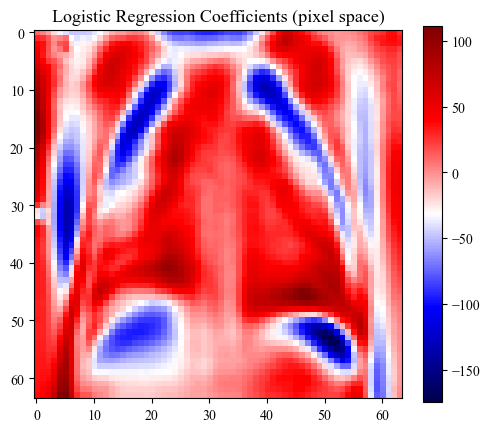

In [9]:
# Project regression coefficients back to pixel space for visualization
W_pixel = pca.components_.T @ W[1:]  # (4096, 50) @ (50, 1) = (4096, 1)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=[5, 5])
im = ax.imshow(W_pixel.reshape(IMG_SIZE, IMG_SIZE), cmap='seismic')
ax.set_title('Logistic Regression Coefficients (pixel space)', fontsize=13)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()

In [22]:
# Get predicted probabilities on test set
H_test = np.vstack((np.ones(X_test_pca.shape[0]), X_test_pca.T))
Q = 1 / (1 + np.exp(-H_test.T @ W))  # predicted probabilities

# Convert probabilities to binary predictions (threshold = 0.5)
Y_pred = (Q >= 0.5).astype(int)

print('Sample predictions (first 10):')
print('  Predicted probs: ', np.round(Q[:10].flatten(), 3))
print('  Predicted labels:', Y_pred[:10].flatten())
print('  True labels:     ', y_test[:10].flatten())

Sample predictions (first 10):
  Predicted probs:  [0. 1. 1. 0. 1. 0. 1. 0. 0. 0.]
  Predicted labels: [0 1 1 0 1 0 1 0 0 0]
  True labels:      [0 0 0 0 0 0 0 0 0 0]


C:\Users\Adrian Orozco\AppData\Local\Temp\ipykernel_21944\3398461665.py:3: RuntimeWarning: overflow encountered in exp
  Q = 1 / (1 + np.exp(-H_test.T @ W))  # predicted probabilities


## Evaluation

In [ ]:
def compute_accuracy_metrics(Y_test, P_pred, threshold=0.5):
    """
    Y_test = binary label
    P_pred = predicted probability
    """
    Y_pred = (P_pred >= threshold).astype(int)

    mcm = confusion_matrix(Y_test, Y_pred)
    tn = mcm[0, 0]
    tp = mcm[1, 1]
    fn = mcm[1, 0]
    fp = mcm[0, 1]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)      # recall: how many actual positives are caught
    specificity = tn / (tn + fp)      # how many actual negatives are correctly identified
    precision = tp / (tp + fp)
    f1_score = 2 * precision * sensitivity / (precision + sensitivity)

    results_dict = {
        'Y_test': Y_test,
        'Y_pred': Y_pred,
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1-score': f1_score,
    }
    return results_dict

In [13]:
# Compute binary classification accuracies
result_dict = compute_accuracy_metrics(Y_test=y_test, P_pred=Q)

# Print out the results 
keys_list = [i for i in result_dict.keys()]
for key in keys_list:
    if key not in ['Y_test', 'Y_pred']:
        print('%s = %f' % (key, result_dict.get(key)))

Accuracy = 0.818910
Sensitivity = 0.542735
Specificity = 0.984615
Precision = 0.782077
F1-score = 0.640786


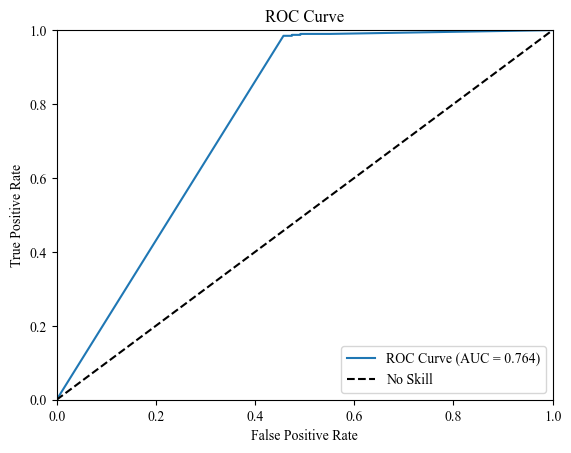

In [14]:
#AUC and ROC computation and plotting

def auc_metric_roc_curve(Y_test, P_pred):
    #Get auc-roc metrics
    fpr, tpr, threshold = metrics.roc_curve(Y_test, P_pred, pos_label=None)
    myauc = metrics.auc(fpr, tpr)

    #Print ROC curve
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {myauc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.legend()

#Call the function using y_test and Q
auc_metric_roc_curve(y_test,Q)

C:\Users\Adrian Orozco\AppData\Local\Temp\ipykernel_21944\1870870098.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['','Normal','Pneumonia'], fontsize = 12)
C:\Users\Adrian Orozco\AppData\Local\Temp\ipykernel_21944\1870870098.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['','Normal','Pneumonia'], fontsize = 12)


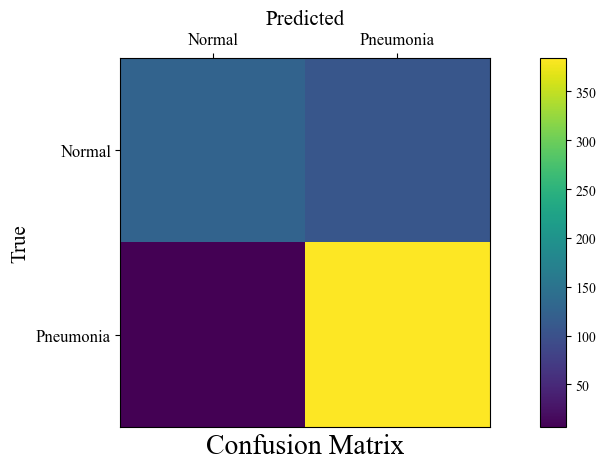

In [62]:
# Compute confusion matrix
cm = confusion_matrix(y_test, Y_pred)

# Plot confusion matrix
fig, ax = plt.subplots()
im_confusion = ax.matshow(cm)
ax.set_title("Predicted", fontsize = 15)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='7%', pad=0.5) 
fig.colorbar(im_confusion, cax=cax)
ax.set_xticklabels(['','Normal','Pneumonia'], fontsize = 12)
ax.set_yticklabels(['','Normal','Pneumonia'], fontsize = 12)
ax.set_ylabel('True', fontsize = 15)
ax.set_xlabel('Confusion Matrix', fontsize = 20)
ax.tick_params(bottom=False, labelbottom=False)
fig.tight_layout()

In [ ]:
# K-fold cross-validation
from sklearn.model_selection import KFold

# Combine all data for cross-validation
X_all_pca = np.vstack([X_train_pca, X_test_pca])
y_all = np.vstack([y_train, y_test])

k = 12
cv = KFold(n_splits=k, shuffle=True, random_state=42)

Accuracies = []
F1_scores = []
Sensitivities = []

for fold, (train_index, test_index) in enumerate(cv.split(X_all_pca)):
    X_train_fold = X_all_pca[train_index]
    y_train_fold = y_all[train_index]
    X_test_fold = X_all_pca[test_index]
    y_test_fold = y_all[test_index]

    # Feature matrix with bias row
    H_train_fold = np.vstack((np.ones(X_train_fold.shape[0]), X_train_fold.T))

    # Fit logistic regression
    W_fold = fit_LR_GD(Y=y_train_fold, H=H_train_fold, sub_iter=300)

    # Predict on test fold
    H_test_fold = np.vstack((np.ones(X_test_fold.shape[0]), X_test_fold.T))
    Q_fold = 1 / (1 + np.exp(-H_test_fold.T @ W_fold))

    result_dict = compute_accuracy_metrics(y_test_fold, Q_fold)

    Accuracies.append(result_dict['Accuracy'])
    F1_scores.append(result_dict['F1-score'])
    Sensitivities.append(result_dict['Sensitivity'])

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

plot_data = {
    'Accuracy': Accuracies,
    'F1-score': F1_scores,
    'Sensitivity': Sensitivities,
}

for i, (name, values) in enumerate(plot_data.items()):
    avg = np.mean(values)
    axes[i].bar(np.arange(k), values, color='steelblue', alpha=0.8)
    axes[i].axhline(y=avg, color='red', linestyle='--', label=f'Mean = {avg:.4f}')
    axes[i].set_xlabel('Fold', fontsize=13)
    axes[i].set_ylabel(name, fontsize=13)
    axes[i].set_title(f'{k}-Fold Cross-Validation: {name}', fontsize=15)
    axes[i].set_xticks(np.arange(k))
    axes[i].legend(fontsize=12)

fig.tight_layout()
print(f'Mean Accuracy:    {np.mean(Accuracies):.4f} ± {np.std(Accuracies):.4f}')
print(f'Mean F1-score:    {np.mean(F1_scores):.4f} ± {np.std(F1_scores):.4f}')
print(f'Mean Sensitivity: {np.mean(Sensitivities):.4f} ± {np.std(Sensitivities):.4f}')

In [ ]:
# Learning Curves: Training vs Validation Loss as a function of training set size

from sklearn.model_selection import train_test_split

def compute_log_loss(Y, H, W):
    """Compute logistic regression negative log-likelihood (cross-entropy loss)."""
    z = H.T @ W
    # Clip to avoid log(0)
    z = np.clip(z, -500, 500)
    loss = np.sum(np.log(1 + np.exp(z)) - Y * z) / Y.shape[0]
    return loss

# Split training data into train and validation (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Increasing fractions of training data
fractions = np.linspace(0.1, 1.0, 10)
train_losses = []
val_losses = []
train_sizes = []

# Precompute validation feature matrix
H_val = np.vstack((np.ones(X_val.shape[0]), X_val.T))

for frac in fractions:
    n_samples = int(frac * X_tr.shape[0])
    X_sub = X_tr[:n_samples]
    y_sub = y_tr[:n_samples]

    H_sub = np.vstack((np.ones(X_sub.shape[0]), X_sub.T))

    W_sub = fit_LR_GD(Y=y_sub, H=H_sub, sub_iter=300)

    train_loss = compute_log_loss(y_sub, H_sub, W_sub)
    val_loss = compute_log_loss(y_val, H_val, W_sub)

    train_sizes.append(n_samples)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_losses, 'o-', label='Training Loss', color='steelblue')
ax.plot(train_sizes, val_losses, 's-', label='Validation Loss', color='darkorange')
ax.set_xlabel('Training Set Size', fontsize=13)
ax.set_ylabel('Log Loss (Cross-Entropy)', fontsize=13)
ax.set_title('Learning Curves: Training vs Validation Loss', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()